<a href="https://colab.research.google.com/github/RyanSVargas/Quant-Finance-Research/blob/main/06_Time_Series_Forecasting/Volatility_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install arch -q
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# 1. Get Data (BTC is perfect because it has high volatility)
ticker = 'BTC-USD'
data = yf.download(ticker, start='2020-01-01', auto_adjust=True)['Close']

# 2. Calculate Returns (GARCH requires returns scaled by 100 usually for convergence)
returns = 100 * data.pct_change().dropna()

# 3. Fit the GARCH(1,1) Model
# 'Constant Mean' + 'GARCH' volatility is the standard setup
model = arch_model(returns, vol='Garch', p=1, q=1)
results = model.fit(disp='off')

print(results.summary())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.5 MB/s eta 0:00:00


[*********************100%***********************]  1 of 1 completed

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                BTC-USD   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5633.80
Distribution:                  Normal   AIC:                           11275.6
Method:            Maximum Likelihood   BIC:                           11298.4
                                        No. Observations:                 2236
Date:                Sun, Feb 15 2026   Df Residuals:                     2235
Time:                        00:09:44   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1833  5.973e-02      3.070  2.144e-03 [6.627e-0

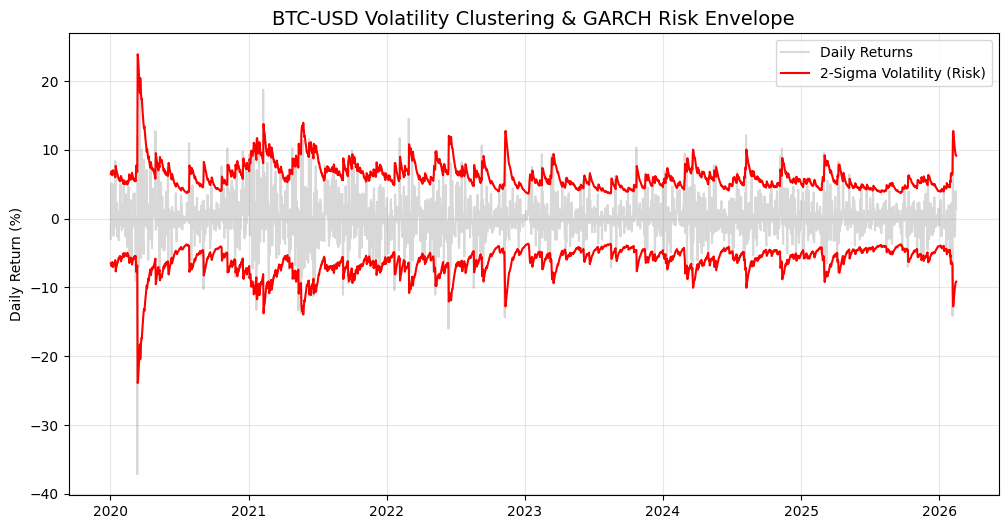

In [ ]:
# 4. Plotting the "Risk Regime"
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Actual Returns (Grey noise)
ax.plot(returns.index, returns, color='grey', alpha=0.3, label='Daily Returns')

# Plot Estimated Volatility (Red line of danger)
# We multiply by 2 to show the 2-Sigma (95% confidence) envelope
conditional_volatility = results.conditional_volatility
ax.plot(returns.index, 2 * conditional_volatility, color='red', label='2-Sigma Volatility (Risk)', linewidth=1.5)
ax.plot(returns.index, -2 * conditional_volatility, color='red', linewidth=1.5)

ax.set_title(f'{ticker} Volatility Clustering & GARCH Risk Envelope', fontsize=14)
ax.set_ylabel('Daily Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


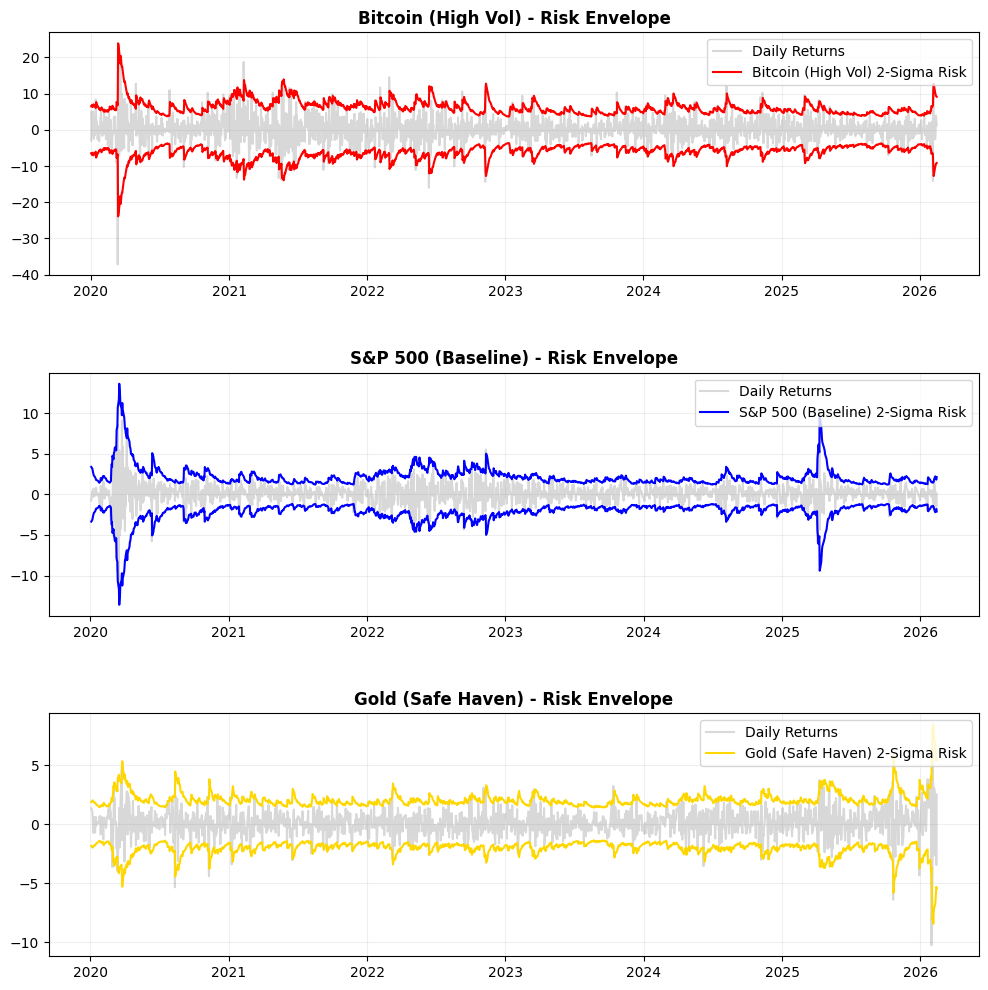

In [ ]:
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model

# 1. Define Scenarios
assets = ['BTC-USD', 'SPY', 'GLD']
colors = ['red', 'blue', 'gold']
names = ['Bitcoin (High Vol)', 'S&P 500 (Baseline)', 'Gold (Safe Haven)']

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
plt.subplots_adjust(hspace=0.4)

# 2. Loop through each asset and run GARCH
for i, ticker in enumerate(assets):
    # Fetch Data
    data = yf.download(ticker, start='2020-01-01', progress=False, auto_adjust=True)['Close']
    returns = 100 * data.pct_change().dropna()

    # Fit GARCH(1,1)
    model = arch_model(returns, vol='Garch', p=1, q=1)
    res = model.fit(disp='off')

    # Get Volatility
    vol = res.conditional_volatility

    # Plot
    ax = axes[i]
    ax.plot(returns.index, returns, color='grey', alpha=0.3, label='Daily Returns')
    ax.plot(returns.index, 2*vol, color=colors[i], label=f'{names[i]} 2-Sigma Risk')
    ax.plot(returns.index, -2*vol, color=colors[i])

    ax.set_title(f'{names[i]} - Risk Envelope', fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

plt.show()
